# Weather Model Performance

Train and test the **next-day high/low** temperature model. Uses Open-Meteo for features and **NWS for targets only**. Time-based train/validation split; metrics and plots below.

## 1. Load data and build training dataset

In [9]:
from pathlib import Path
import pandas as pd

from weather_modeling.pipeline import build_training_data, add_nws_targets
from weather_modeling.storage import load_data, load_nws_data

data_dir = Path("data")
hourly, daily = load_data(data_dir)
nws_df = load_nws_data(data_dir)

if daily.empty or hourly.empty:
    raise SystemExit("No data in data/. Run: python main.py train")
if nws_df.empty:
    raise SystemExit("No NWS data. Run: python main.py nws (or backfill_nws.py)")

df = build_training_data(daily, hourly)
df = add_nws_targets(df, nws_df)
df = df.dropna(subset=["lag1_max", "lag1_min"])
df = df.dropna(subset=["target_next_day_high", "target_next_day_low"])
df["date"] = pd.to_datetime(df["date"])

print(f"Total rows: {len(df)}")
print(f"Cities: {df['city'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

ImportError: cannot import name 'add_nws_targets' from 'data_collector' (/Users/christophersemling/projects/weather_modeling/data_collector.py)

## 2. Time-based train/validation split

In [ ]:
# Last 20% of days (by date) as validation
all_dates = df["date"].dt.date.unique()
all_dates = sorted(all_dates)
split_idx = int(len(all_dates) * 0.8)
val_start = all_dates[split_idx]

train_df = df[df["date"].dt.date < val_start].copy()
valid_df = df[df["date"].dt.date >= val_start].copy()

# Drop rows with missing targets for training and validation
train_df = train_df.dropna(subset=["target_next_day_high", "target_next_day_low"])
valid_df = valid_df.dropna(subset=["target_next_day_high", "target_next_day_low"])

print(f"Train: {len(train_df)} rows ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Valid: {len(valid_df)} rows ({valid_df['date'].min().date()} to {valid_df['date'].max().date()})")

Train: 447 rows (2026-02-05 to 2026-02-25)
Valid: 136 rows (2026-02-26 to 2026-03-03)


## 3. Train model

In [ ]:
from model import train_models, save_artifact

artifact = train_models(train_df)

print("Training set MAE (in-sample):")
for target, m in artifact["metrics"].items():
    print(f"  {target}: {m['mae']:.2f} °F")

# Save for use by predict.py
save_artifact(artifact, Path("models/artifact.pkl"))
print("\nSaved artifact to models/artifact.pkl")

Training set MAE (in-sample):
  target_next_day_high: 1.11 °C
  target_next_day_low: 0.86 °C

Saved artifact to models/artifact.pkl


## 4. Validation set performance

In [ ]:
from model import predict
from sklearn.metrics import mean_absolute_error

pred_df = predict(valid_df, artifact)

targets = ["target_next_day_high", "target_next_day_low"]
val_metrics = {}
for t in targets:
    pred_col = t.replace("target_", "pred_")
    val_metrics[t] = mean_absolute_error(valid_df[t], pred_df[pred_col])

print("Validation set MAE (out-of-sample):")
for target, mae in val_metrics.items():
    print(f"  {target}: {mae:.2f} °F")

Validation set MAE (out-of-sample):
  target_next_day_high: 3.80 °C
  target_next_day_low: 2.45 °C


## 5. Performance summary table

In [ ]:
summary = pd.DataFrame({
    "Target": [t.replace("target_", "").replace("_", " ") for t in targets],
    "Train MAE (°F)": [artifact["metrics"][t]["mae"] for t in targets],
    "Valid MAE (°F)": [val_metrics[t] for t in targets],
})
summary

,Target,Train MAE (°C),Valid MAE (°C)
0,next day high,1.107977,3.803413
1,next day low,0.858220,2.448519


## 6. Predicted vs actual (validation set)

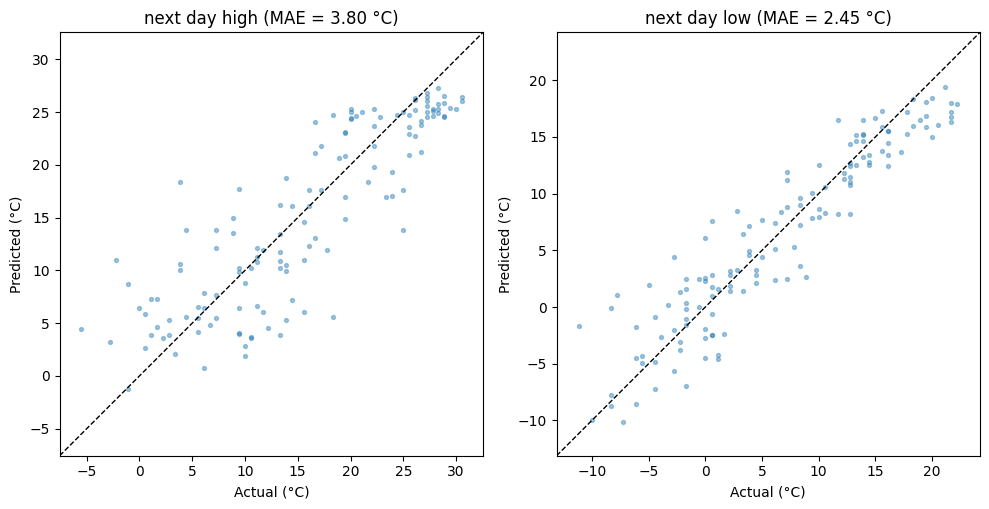

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

for ax, target in zip(axes, targets):
    pred_col = target.replace("target_", "pred_")
    y_true = valid_df[target]
    y_pred = pred_df[pred_col]
    ax.scatter(y_true, y_pred, alpha=0.4, s=8)
    lims = [min(y_true.min(), y_pred.min()) - 2, max(y_true.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, "k--", lw=1, label="Perfect")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual (°F)")
    ax.set_ylabel("Predicted (°F)")
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f"{target.replace('target_', '').replace('_', ' ')} (MAE = {mae:.2f} °F)")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 7. Residual distributions

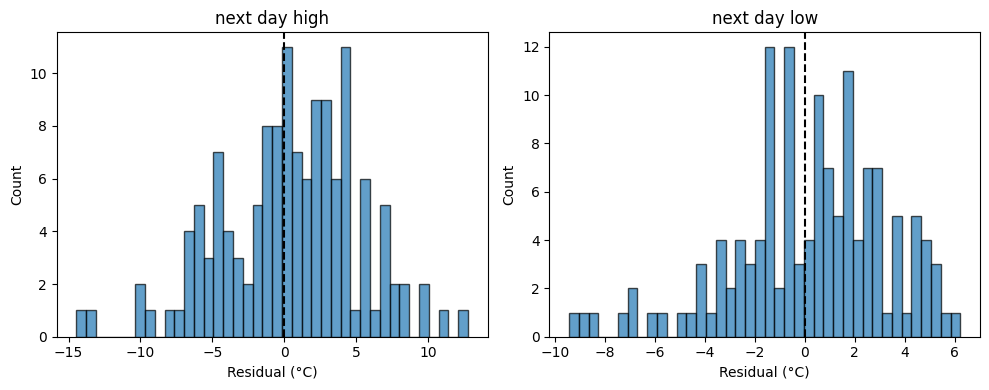

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for ax, target in zip(axes, targets):
    pred_col = target.replace("target_", "pred_")
    resid = valid_df[target].values - pred_df[pred_col].values
    ax.hist(resid, bins=40, edgecolor="black", alpha=0.7)
    ax.axvline(0, color="k", linestyle="--")
    ax.set_xlabel("Residual (°F)")
    ax.set_ylabel("Count")
    ax.set_title(target.replace("target_", "").replace("_", " "))

plt.tight_layout()
plt.show()

## 8. MAE by city (validation)

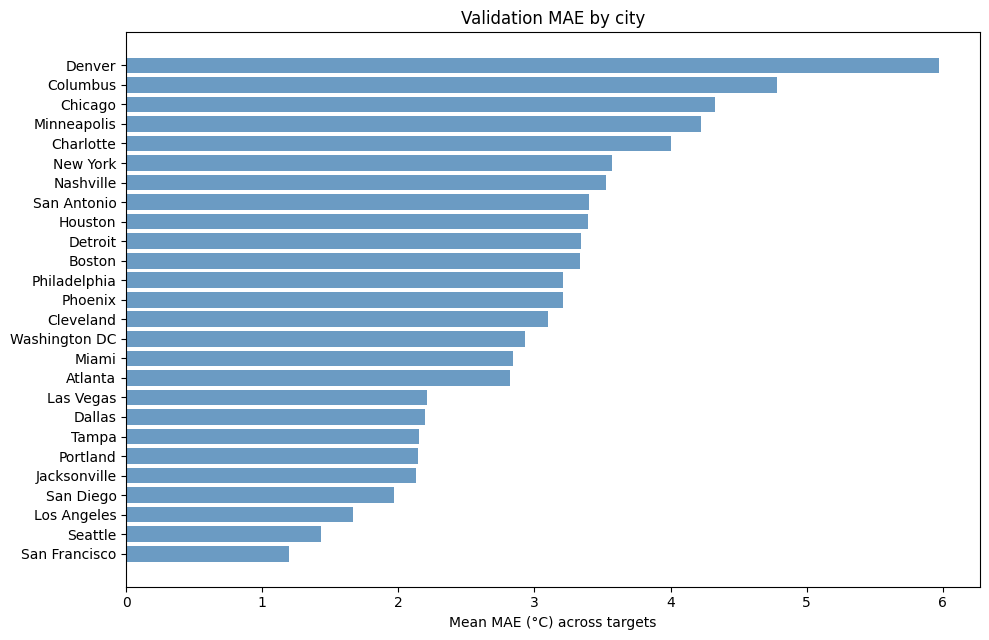

,city,target_next_day_high,target_next_day_low,mean_mae
22,San Francisco,1.68,0.71,1.19
23,Seattle,1.29,1.57,1.43
12,Los Angeles,2.18,1.15,1.66
21,San Diego,2.39,1.55,1.97
10,Jacksonville,2.65,1.60,2.13
19,Portland,2.34,1.94,2.14
24,Tampa,2.61,1.68,2.15
6,Dallas,2.08,2.31,2.20
11,Las Vegas,1.56,2.86,2.21
0,Atlanta,3.64,2.00,2.82


In [ ]:
city_mae = []
for city in valid_df["city"].unique():
    mask = pred_df["city"] == city
    row = {"city": city}
    for t in targets:
        pred_col = t.replace("target_", "pred_")
        row[t] = mean_absolute_error(valid_df.loc[mask, t], pred_df.loc[mask, pred_col])
    city_mae.append(row)

city_df = pd.DataFrame(city_mae)
city_df["mean_mae"] = city_df[[t for t in targets]].mean(axis=1)
city_df = city_df.sort_values("mean_mae")

fig, ax = plt.subplots(figsize=(10, max(6, len(city_df) * 0.25)))
y_pos = range(len(city_df))
ax.barh(y_pos, city_df["mean_mae"], color="steelblue", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(city_df["city"])
ax.set_xlabel("Mean MAE (°F) across targets")
ax.set_title("Validation MAE by city")
plt.tight_layout()
plt.show()

city_df.round(2)